# Ex. No: 12
# PROJECT: Face Detection with Haar Cascades

### **Name:** KISHORE J   **Reg.** 212225240072

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 1: Read the image and convert the image into RGB
image = cv2.imread('myimg.jpeg')  # Replace with your image path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

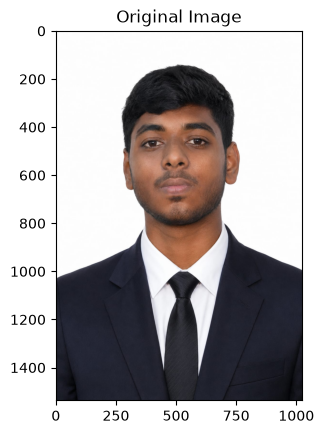

In [3]:
# Step 2: Display the original image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('on')
plt.show()

In [4]:
# Step 4: Set the pixels to display the ROI (Region of Interest)
# Define the coordinates for the Region of Interest (ROI)
# (startY:endY, startX:endX)
roi = image[100:420, 200:550]  # ROI coordinates (adjust as needed)

# Create a blank mask of the same size as the original image
mask = np.zeros_like(image)

# Place the ROI on the mask
mask[100:420, 200:550] = roi

In [5]:
# Step 5: Perform bitwise conjunction of the two arrays using bitwise_and
segmented_roi = cv2.bitwise_and(image, mask)

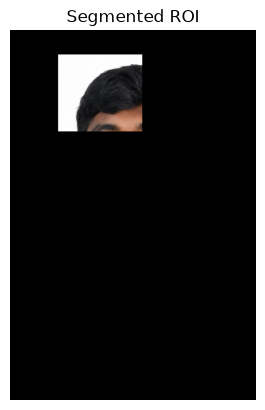

In [6]:
# Step 6: Display the segmented ROI from the image
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)
plt.imshow(segmented_roi_rgb)
plt.title("Segmented ROI")
plt.axis('off')
plt.show()

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Step 1: Read the image and convert it to RGB for displaying
image = cv2.imread('img.jpg')  # Replace with your actual image file path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

(np.float64(-0.5), np.float64(611.5), np.float64(458.5), np.float64(-0.5))

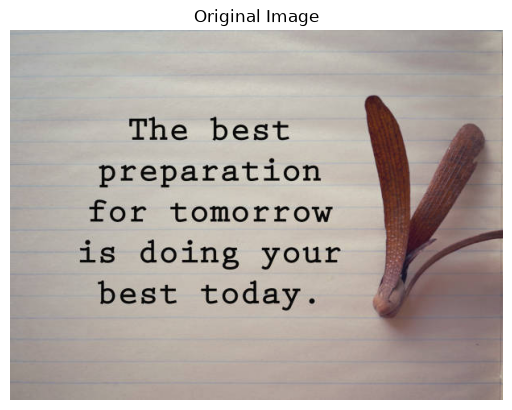

In [9]:
# Original Image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

In [10]:
# Step 2: Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

In [11]:
# Step 3: Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)  # Apply Gaussian blur (5x5 kernel)

In [12]:
# Step 5: Use Canny edge detector to find edges
edges = cv2.Canny(blurred_image, 50, 150)  # Detect edges using Canny (thresholds 50 and 150)

(np.float64(-0.5), np.float64(611.5), np.float64(458.5), np.float64(-0.5))

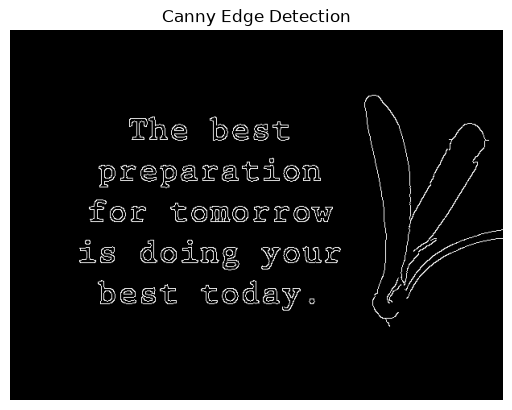

In [13]:
# Canny Edge Detection
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

In [14]:
# Step 6: Find contours in the edged image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [15]:
# Step 7: Filter contours based on area and draw bounding boxes
result_image = image.copy()  # Create a copy of the original image to draw bounding boxes
for contour in contours:
    if cv2.contourArea(contour) > 50:  # Filter out small areas
        x, y, w, h = cv2.boundingRect(contour)  # Get the bounding box for the contour
        cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw the rectangle

(np.float64(-0.5), np.float64(611.5), np.float64(458.5), np.float64(-0.5))

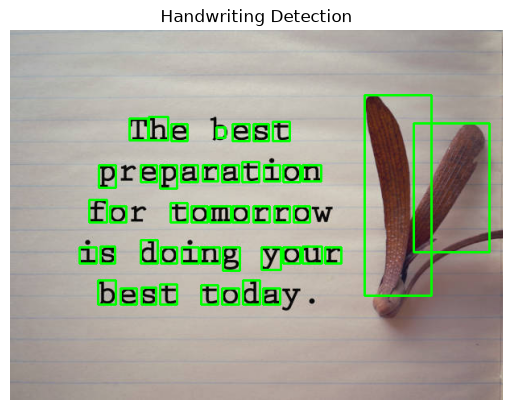

In [16]:
# Handwriting Detection Result
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Handwriting Detection")
plt.axis('off')

In [15]:
import cv2
import matplotlib.pyplot as plt

model = cv2.imread("myimg.jpeg")

print(model.shape)

(1537, 1023, 3)


In [16]:
import cv2
import urllib.request
import os

url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"

save_path = os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml")

urllib.request.urlretrieve(url, save_path)

print("Downloaded:", save_path)
print("Exists:", os.path.exists(save_path))


Downloaded: C:\Users\acer\anaconda3\envs\opencv-env\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
Exists: True


In [17]:
face_cascade = cv2.CascadeClassifier(save_path)

print("Loaded:", not face_cascade.empty())

Loaded: True


In [18]:
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise RuntimeError(
        f"Face cascade could not be loaded.\nPath: {face_cascade_path}"
    )

print("Face cascade loaded successfully!")

Face cascade loaded successfully!


In [19]:
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise RuntimeError(
        f"Face cascade could not be loaded.\nPath: {face_cascade_path}"
    )

print("Face cascade loaded successfully!")
print(face_cascade_path)

Face cascade loaded successfully!
C:\Users\acer\anaconda3\envs\opencv-env\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


In [20]:
def detect_face(img):
    face_img = img.copy()

    # Convert to grayscale if the image is colored
    if len(face_img.shape) == 3:
        gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_img

    face_rects = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in face_rects:
        cv2.rectangle(
            face_img,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            3
        )

    return face_img

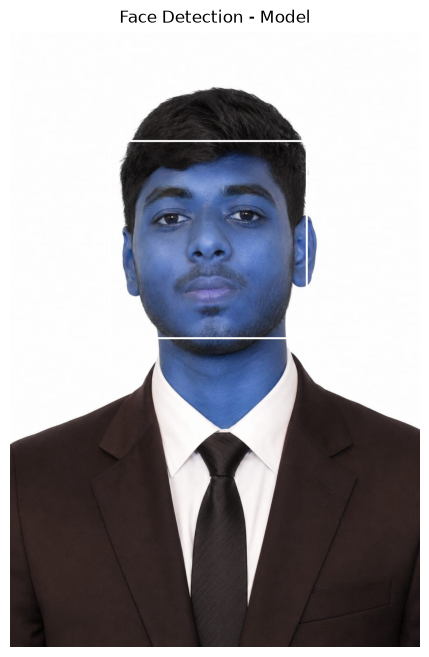

In [21]:
result = detect_face(model)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face Detection - Model")
plt.axis('off')
plt.show()